# 一、微博关键词爬虫

In [56]:
#微博爬虫：https://s.weibo.com/,按“瑞幸”搜索
from selenium import webdriver
from lxml import etree
import time,datetime,xlwt,xlrd,os,re
from xlutils.copy import copy
from urllib import parse
                 
def parse_time(time_str):
    if '分钟前' in time_str:
        time_temp = int(time_str.split('分钟前')[0])
        new_time = (datetime.datetime.now() + datetime.timedelta(minutes=time_temp)).strftime("%Y-%m-%d %H:%M")
    elif '今天' in time_str:
        time_temp = time_str.split('今天')[1]
        new_time = (datetime.datetime.now()).strftime("%Y-%m-%d") + ' ' +time_temp
    elif '月' in time_str and '日' in time_str:
        time_temp = time_str.replace('月','-').replace('日','-')
        new_time = (datetime.datetime.now()).strftime("%Y") + '-' +time_temp
    else:
        new_time=''
    return new_time



# 创建excel表
def create_wookbook(sheetheader):
    workbook = xlwt.Workbook()
    worksheet = workbook.add_sheet('weibo')
    # 写入表头
    for h in range(0, len(sheetheader)):
        worksheet.write(0, h, sheetheader[h])
    workbook.save('../weibo.xls')


# 写入数据  
def write_into_workbook(rows, content_info_list):
    oldWb = xlrd.open_workbook('../weibo.xls')  # 先打开已存在的表
    newWb = copy(oldWb)  # 复制
    newWs = newWb.get_sheet(0)  # 取sheet表
    for ex in content_info_list:
        for col in range(0, len(ex)):
            newWs.write(rows, col, ex[col])
        rows += 1
    newWb.save('../weibo.xls')
    return rows

def weibo(key_word,user_name,user_key,pages):
#     file_set = open('../采集设置.txt','r')
#     file_read = file_set.read()
#     key_word = re.search(r"(?<=关键词:)(.+?)[\s]",file_read).group(1)
#     user_name = re.search(r"(?<=用户名:)(.+?)[\s]",file_read).group(1)
#     user_key = re.search(r"(?<=密码:)(.+?)[\s]",file_read).group(1)
#     pages = int(re.search(r"(?<=采集页数:)(.+?)[\s]",file_read).group(1))
    dict_weibo ={'q':key_word,'wvr':'6','b':'1','Refer':'SWeibo_box'}

    print('采集关键词:{},采集页数:{}'.format(key_word,pages))
    start_url = 'https://s.weibo.com/weibo?'+parse.urlencode(dict_weibo)
    sheetheader = ['编号', '用户名', '用户链接', '会员类型', '评论内容', '评论时间', '来自','转发','评论','点赞']
    if not os.path.exists('../weibo.xls'):
        create_wookbook(sheetheader)
    rows =1
    driver = webdriver.Chrome()
    driver.get('https://s.weibo.com/')
    time.sleep(2)
    html = etree.HTML(driver.page_source)
    if html.xpath('//*[@id="weibo_top_public"]/div/div/div[3]/div[2]/ul/li[3]/a'):
        driver.find_element_by_xpath('//*[@id="weibo_top_public"]/div/div/div[3]/div[2]/ul/li[3]/a').click()

    time.sleep(2)
    input_user = driver.find_element_by_xpath('.//input[@action-data="text=邮箱/会员帐号/手机号"]')
    time.sleep(2)
    input_user.clear()
    input_user.send_keys(user_name)#输入账号
    time.sleep(2)
    input_key = driver.find_element_by_xpath('.//input[@type="password"]')
    input_key.clear()
    input_key.send_keys(user_key)#输入密码
    driver.find_element_by_xpath('.//span[@class="enter_psw"]/../../div[@class="item_btn"]/a').click() #点击登录
    time.sleep(2)

    for page in range(1,pages+1):
        url = (start_url+'&page={}').format(page)
        driver.get(url)  
        html = etree.HTML(driver.page_source)
        item = html.xpath('.//div[@class="card-wrap" and @action-type="feed_list_item"]')
        content_info = {}
        content_info_list = []
        for i in item:
            # content_info['page'] = page
            content_info['mid'] = "".join(i.xpath('./@mid')).strip()
            content_info['user_name'] = "".join(i.xpath('.//descendant::div[@class="content"]/div/div/a[@class="name"]/@nick-name')).strip()
            content_info['user_link'] = 'https:'+"".join(i.xpath('.//descendant::div[@class="content"]/div/div/a[@class="name"]/@href')).strip().split('?re')[0]
            content_info['user_type'] = "".join(i.xpath('.//descendant::div[@class="content"]/div/div/a[@target="_blank" and @title]/@title')).strip()
            content_info['content_txt'] = "".join(i.xpath('.//descendant::div[@class="content"]/p[@class="txt"][position()=last()]//text()')).strip()
            content_info['content_time'] = "".join(i.xpath('.//descendant::div[@class="content"]/p[@class="from"]/a[@suda-data]/text()')).strip()
            if content_info['content_time'] == '':
                content_info['content_time'] = ''
            else:
                content_info['content_time'] = parse_time(content_info['content_time'])
            content_info['phone_nofollow'] = "".join(i.xpath('.//descendant::div[@class="content"]/p[@class="from"]/a[@rel="nofollow"]/text()')).strip()
            content_info['content_zhuanfa'] = "".join(i.xpath('.//descendant::div[@class="card-act"]/ul/li[2]//text()')).strip().replace('转发','')
            content_info['content_pinglu'] = "".join(i.xpath('.//descendant::div[@class="card-act"]/ul/li[3]//text()')).strip().replace('评论','')
            content_info['content_dianzan'] = "".join(i.xpath('.//descendant::div[@class="card-act"]/ul/li[4]//text()')).strip().replace('赞','')
            
     
            content_info_list.append(list(content_info.values()))
        print(content_info_list)
        rows = write_into_workbook(rows, content_info_list)
        time.sleep(2)
    print('采集完成')
    driver.close()
if __name__ =='__main__':
    key_word = input('请输入采集关键词：')
    user_name = input('请输入微博用户名：')
    user_key = input('请输入微博密码：')
    pages = 50 #采集页数
    weibo(key_word,user_name,user_key,pages)


请输入采集关键词：jdj
请输入微博用户名：dlkf
请输入微博密码：dlkjf
采集关键词:jdj,采集页数:50
jdj dlkf dlkjf 50


# 二、情感评分分析

In [42]:
#情感评分分析
from aip import AipNlp
import csv,re
import pandas as pd
import numpy as np

""" 你的 APPID AK SK """
# 利用百度云提供的API接口实现情感分析
# https://cloud.baidu.com/product/nlp/sentiment_classify
APP_ID = ''
API_KEY = ''
SECRET_KEY = ''
client = AipNlp(APP_ID, API_KEY, SECRET_KEY)

#清洗Unicode编码字符串https://www.jianshu.com/p/4958bcdea12a
def illegal_char(s):
    s = re.compile( \
        u"[^"
        u"\u4e00-\u9fa5"
        u"\u0041-\u005A"
        u"\u0061-\u007A"
        u"\u0030-\u0039"
        u"\u3002\uFF1F\uFF01\uFF0C\u3001\uFF1B\uFF1A\u300C\u300D\u300E\u300F\u2018\u2019\u201C\u201D\uFF08\uFF09\u3014\u3015\u3010\u3011\u2014\u2026\u2013\uFF0E\u300A\u300B\u3008\u3009"
        u"\!\@\#\$\%\^\&\*\(\)\-\=\[\]\{\}\\\|\;\'\:\"\,\.\/\<\>\?\/\*\+"
        u"]+").sub('', s)
    return s


# 对读入的数据进行情感分析，将其得到的结果解析成标准JSON格式数据，并保存在一个新的dict中
def senti_anlaly(text):
    text = illegal_char(text)
    data = client.sentimentClassify(text)
    sentiment =data['items'][0]['positive_prob']
    return sentiment

datas = pd.read_excel('weibo_luckin.xls',sheet_name='weibo',header=0,encoding = "gbk")
sentiments = []
for s in list(datas['评论内容']):
    sentiments.append(senti_anlaly(s))


# 三、数据分析

In [46]:
print('情感评分平均得分:'+str(np.mean(sentiments)))

情感评分平均得分:0.69666721661


In [47]:
print('情感评分中位数:'+str(np.median(sentiments)))

情感评分中位数:0.8061065000000001


In [50]:
import math
grades =[]
for s in sentiments:
    grades.append(math.ceil(s*10)/10) 

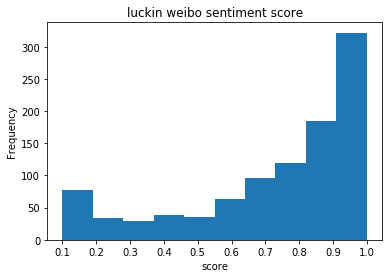

<Figure size 864x864 with 0 Axes>

In [57]:
from matplotlib import pyplot
import math
grades =[]
for s in sentiments:
    grades.append(math.ceil(s*10)/10) 
    
#绘制直方图
def drawHist(sentiments):
    #创建直方图
    #第一个参数为待绘制的定量数据，不同于定性数据，这里并没有事先进行频数统计
    #第二个参数为划分的区间个数
    
    x =[i/10 for i in range(1,11,1)]
    pyplot.hist(sentiments, 10)
    pyplot.xticks(x)
    pyplot.xlabel('score')
    pyplot.ylabel('Frequency')
    pyplot.title('luckin weibo sentiment score')
    pyplot.figure(figsize=(12, 12))
    
    pyplot.show()

drawHist(grades)

In [ ]:
按0.1等间距划分分布，可以很明显的看到情感评分得分集中分布在0.7~1分，且0.9~1分数量还是最多的，超过300个，将近1/3。

d:\ProgramData\Anaconda3\lib\site-packages\matplotlib\axes\_axes.py:6462: UserWarning: The 'normed' kwarg is deprecated, and has been replaced by the 'density' kwarg.
  warnings.warn("The 'normed' kwarg is deprecated, and has been "


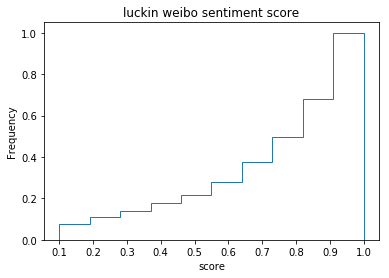

In [53]:
from matplotlib import pyplot

#绘制累积曲线
def drawCumulativeHist(sentiments):
    #创建累积曲线
    #第一个参数为待绘制的定量数据
    #第二个参数为划分的区间个数
    #normed参数为是否无量纲化
    #histtype参数为'step'，绘制阶梯状的曲线
    #cumulative参数为是否累积
    x =[i/10 for i in range(1,11,1)]
    pyplot.hist(sentiments, 10, normed=True, histtype='step', cumulative=True)
    pyplot.xticks(x)
    pyplot.xlabel('score')
    pyplot.ylabel('Frequency')
    pyplot.title('luckin weibo sentiment score')
    pyplot.show()
drawCumulativeHist(grades)
    

In [ ]:
累计分布图中：0.7分以上占了60%。